
  3-Qubit Bit-Flip Code — Pauli Stabilizer Formalism

  Code space stabilizers:
    S1 = Z⊗Z⊗I  (ZZI)  — measures parity of data[0] and data[1]
    S2 = Z⊗I⊗Z  (ZIZ)  — measures parity of data[0] and data[2]

  Logical operators:
    X_L = X⊗X⊗X   (flips all 3 qubits)
    Z_L = Z⊗I⊗I   (Z on any one qubit; ZZZ acts the same way on the code space)
    
  CIRCUIT DIAGRAMS

  -- Encoding (|0_L> or |1_L> -> 3 physical qubits) --
                  ┌───┐
data_0: ──■────■──┤ I ├
        ┌─┴─┐  │  ├───┤
data_1: ┤ X ├──┼──┤ I ├
        └───┘┌─┴─┐├───┤
data_2: ─────┤ X ├┤ I ├
             └───┘└───┘

  -- Stabilizer measurement (S1=ZZI, S2=ZIZ via ancillas) --
                                  
data_0: ──■─────────■─────────────
          │         │             
data_1: ──┼────■────┼─────────────
          │    │    │             
data_2: ──┼────┼────┼────■────────
        ┌─┴─┐┌─┴─┐  │    │  ┌─┐   
 anc_0: ┤ X ├┤ X ├──┼────┼──┤M├───
        └───┘└───┘┌─┴─┐┌─┴─┐└╥┘┌─┐
 anc_1: ──────────┤ X ├┤ 

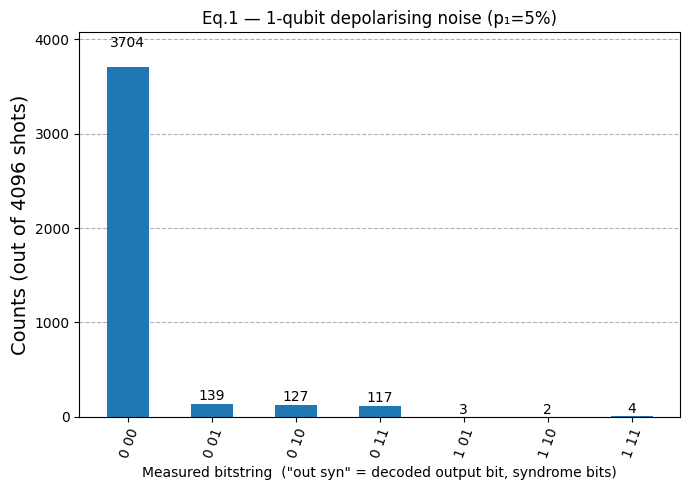

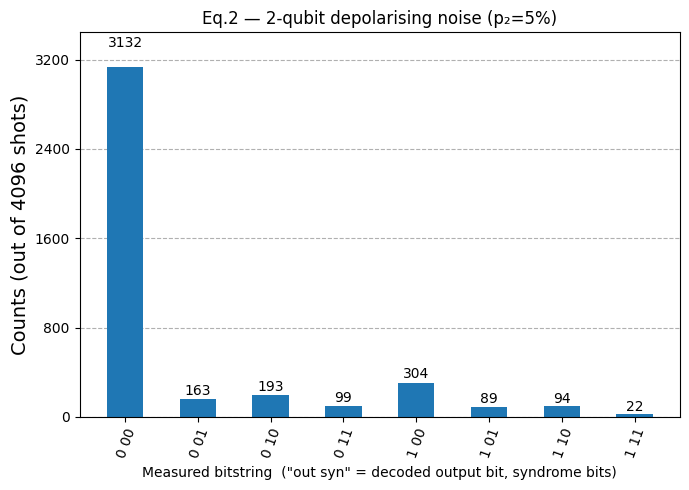

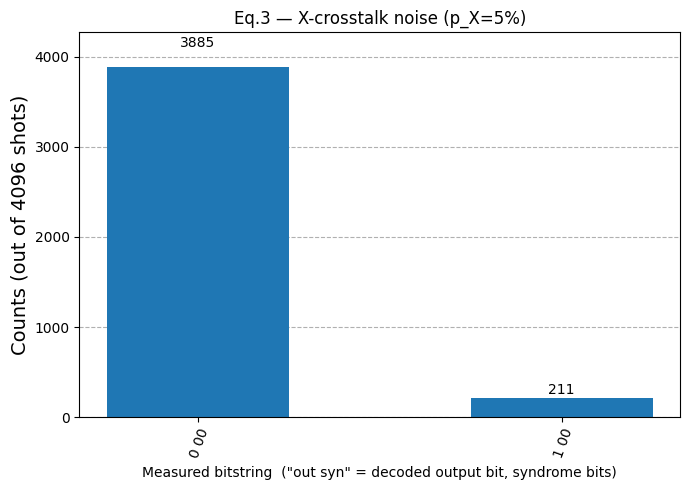

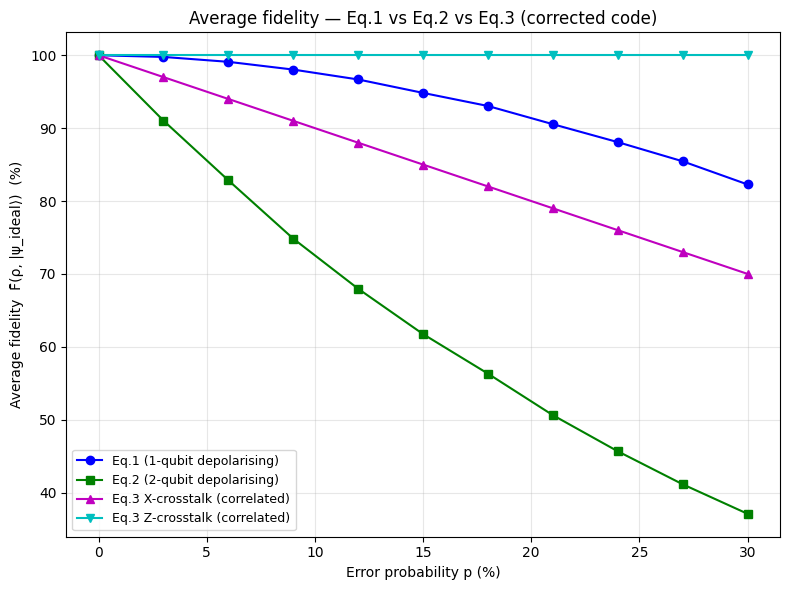

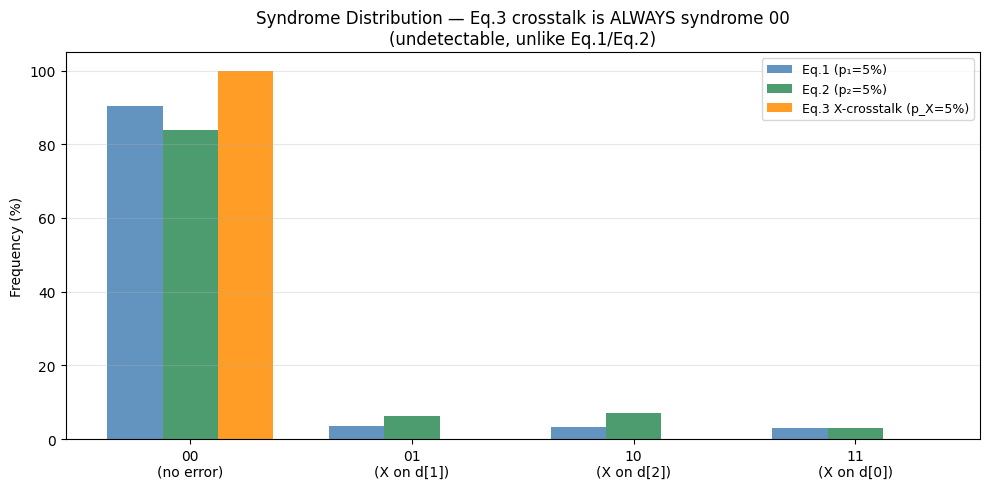

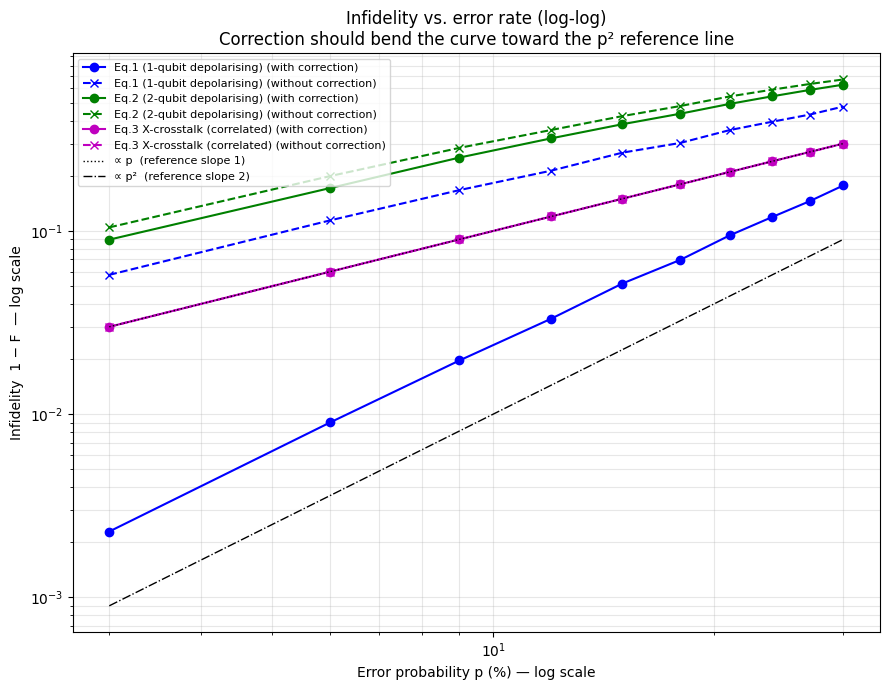

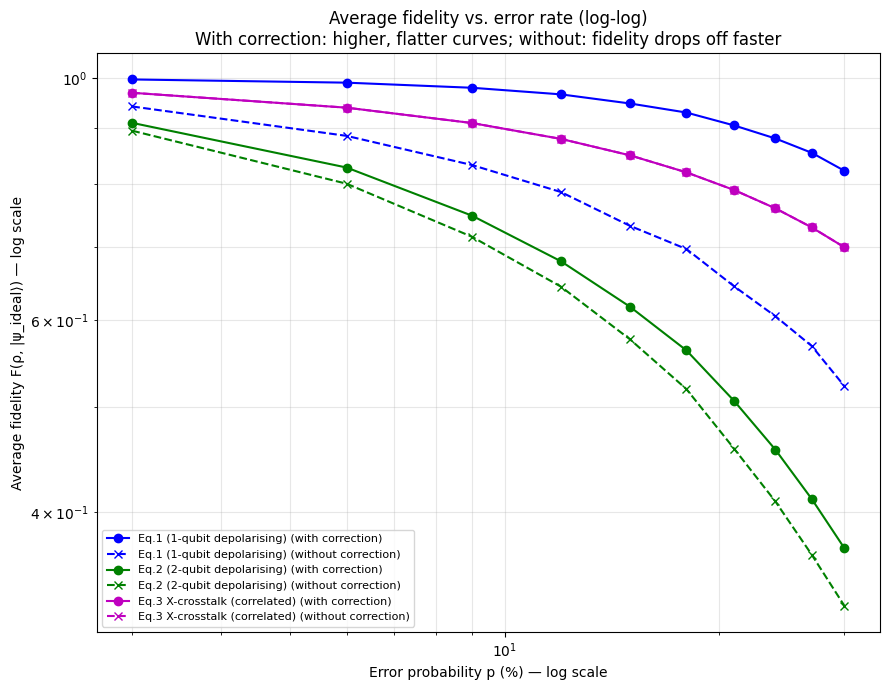


Done.


In [1]:
"""
3-Qubit Bit-Flip Code with Pauli Stabilizer Error Detection & Correction
=========================================================================

The 3-qubit bit-flip code is defined by two STABILIZER GENERATORS:
    S1 = Z⊗Z⊗I  =  ZZI
    S2 = Z⊗I⊗Z  =  ZIZ

These are Pauli operators that leave the code space invariant:
    S1 |000⟩ = +|000⟩,   S1 |111⟩ = +|111⟩
    S2 |000⟩ = +|000⟩,   S2 |111⟩ = +|111⟩

When an X error occurs on qubit k, that qubit anticommutes with Z,
so the stabilizer eigenvalue flips to -1 → measured as |1⟩.

Stabilizer syndrome table (S1=ZZI touches q0,q1 ; S2=ZIZ touches q0,q2):
    S1=+1, S2=+1  (00) → no error
    S1=-1, S2=+1  (10) → X error on q1  ← q1 only sits in S1
    S1=+1, S2=-1  (01) → X error on q2  ← q2 only sits in S2
    S1=-1, S2=-1  (11) → X error on q0  ← q0 sits in BOTH, so both flip

  NOTE (bugfix): an earlier version of this docstring had q0 and q1
  swapped in this table. That was purely a comment-level error — the
  actual decoding logic in build_pauli_correction()/print_results() was
  always correct — but it's fixed here so the table and the code agree.

Three noise phases:
  Phase 1 — Eq.1 noise: single-qubit depolarising on 1-qubit gates
  Phase 2 — Eq.2 noise: two-qubit depolarising on CNOT gates
  Phase 3 — Eq.3 noise: correlated N-body "crosstalk" channel  (NEW)
              E_N(rho) = (1-pX) rho + pX * P rho P ,   P = sigma_i^{⊗N},  i in {X,Y,Z}

  IMPORTANT RESULT (proved analytically below and confirmed numerically):
  For this code, N=3 and P = X^X^X (or Y^Y^Y) is *exactly* the transversal
  logical-X representative. Because logical operators by definition commute
  with every stabilizer generator, this crosstalk channel produces syndrome
  00 with probability 1 -- it is completely invisible to the syndrome
  extraction circuit and therefore CANNOT be detected or corrected by this
  code (or by any stabilizer code, for the same structural reason, whenever
  the correlated error coincides with a logical operator). We demonstrate
  this rather than pretend to "fix" it -- see the PHASE 3 ANALYSIS section
  at the bottom for what can and cannot be done about it.
"""

import numpy as np
from itertools import product as iproduct
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ── Config ─────────────────────────────────────────────────────────────────────
SHOTS         = 4096
P1            = 0.05     # Eq.1 single-qubit depolarising strength
P2            = 0.05     # Eq.2 two-qubit depolarising strength
PX            = 0.05     # Eq.3 crosstalk strength
LOGICAL_STATE = 0        # 0 → |0_L⟩ = |000⟩,  1 → |1_L⟩ = |111⟩
SEED          = 12345    # fixes AerSimulator's RNG so every run/plot is reproducible

# WHAT P1 / P2 / PX ACTUALLY ARE, AND WHY THEY'RE ALL "0.05" HERE
# -----------------------------------------------------------------------------
# P1  = the total probability that a SINGLE-qubit gate (x, u, id) suffers a
#       depolarising error, i.e. gets hit by a random X, Y, or Z with combined
#       probability P1 (so P1/3 each) instead of doing nothing. Plugs into
#       noise_eq1() / Equation 1.
# P2  = the total probability that a TWO-qubit gate (cx) suffers a
#       depolarising error, i.e. one of the 15 nontrivial two-qubit Pauli
#       pairs (IX, XI, XX, XY, ... ZZ) is applied instead of the intended
#       identity, with combined probability P2 (so P2/15 each). Plugs into
#       noise_eq2() / Equation 2.
# PX  = the probability that a CORRELATED crosstalk event fires and applies
#       the SAME Pauli (X, Y, or Z) to all 3 data qubits simultaneously (as
#       opposed to acting on one gate at a time like P1/P2 do). Plugs into
#       noise_eq3_crosstalk() / Equation 3.
# They are set to the same round number (0.05 = 5%) here purely as
# ILLUSTRATIVE, uncalibrated placeholders so the three phases can be compared
# on equal footing in the demo plots below — they are NOT derived from any
# real device or paper. If you want numbers that mean something physically:
#   - P1, P2 : pull calibrated single-/two-qubit gate error rates straight off
#              a real backend via `backend.properties()` (IBM Quantum devices
#              report exactly this per-gate).
#   - PX     : estimate from simultaneous randomized benchmarking (RB) or a
#              crosstalk-characterization experiment, since ordinary
#              (non-simultaneous) RB will not reveal a correlated multi-qubit
#              term like this at all.


# ══════════════════════════════════════════════════════════════════════════════
#  CIRCUIT BLOCKS
# ══════════════════════════════════════════════════════════════════════════════

def build_encoding(logical_state: int) -> QuantumCircuit:
    """
    Encode 1 logical qubit into 3 physical qubits.
    |0_L⟩ = |000⟩,  |1_L⟩ = |111⟩

    NOTE (bugfix): when logical_state == 0, no x/u/id gate is ever placed on
    the data qubits during encoding, since the `if logical_state == 1` branch
    is skipped entirely. noise_eq1() only attaches its depolarising channel
    to ["x", "u", "id"] gates, so with the previous code, running with the
    default LOGICAL_STATE = 0 meant Phase-1 noise had NOTHING to act on
    during encoding (it would still fire later on the conditional correction
    X gates, but the encoding step itself was noise-free) — silently
    understating Eq.1's effect for the default configuration. We add an
    explicit identity gate on every data qubit right after encoding so
    Phase-1 noise always has a 1-qubit gate to act on, regardless of which
    logical state is prepared.
    """
    qr = QuantumRegister(3, "data")
    qc = QuantumCircuit(qr, name="encode")
    if logical_state == 1:
        qc.x(qr[0])          # prepare |1⟩ on data[0]
    qc.cx(qr[0], qr[1])      # fan-out to data[1]
    qc.cx(qr[0], qr[2])      # fan-out to data[2]
    # Explicit identities so Eq.1 (1-qubit) noise is exercised identically
    # regardless of logical_state -- see NOTE above.
    for q in qr:
        qc.id(q)
    return qc


def build_stabilizer_measurement() -> QuantumCircuit:
    """
    Measure the two stabilizer generators using ancilla qubits.

    S1 = ZZI  → anc[0] picks up parity of data[0] ⊕ data[1]
    S2 = ZIZ  → anc[1] picks up parity of data[0] ⊕ data[2]

    Syndrome bits:
        syn[0] = measurement of anc[0]  (S1 = ZZI)
        syn[1] = measurement of anc[1]  (S2 = ZIZ)
    """
    data = QuantumRegister(3, "data")
    anc  = QuantumRegister(2, "anc")
    syn  = ClassicalRegister(2, "syn")
    qc   = QuantumCircuit(data, anc, syn, name="stabilizer_meas")

    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])

    qc.cx(data[0], anc[1])
    qc.cx(data[2], anc[1])

    qc.measure(anc[0], syn[0])
    qc.measure(anc[1], syn[1])

    return qc


def build_pauli_correction() -> QuantumCircuit:
    """
    Apply Pauli X corrections based on the stabilizer syndrome.

      syn[1] syn[0]
         0      0   → no error
         0      1   → X error on data[1]
         1      0   → X error on data[2]
         1      1   → X error on data[0]

    (This matches the corrected syndrome table in the module docstring:
    q1 only anticommutes with S1, q2 only anticommutes with S2, q0
    anticommutes with both. This logic was already correct before the
    docstring fix above -- only the header comment was wrong.)
    """
    data = QuantumRegister(3, "data")
    anc  = QuantumRegister(2, "anc")
    syn  = ClassicalRegister(2, "syn")
    qc   = QuantumCircuit(data, anc, syn, name="pauli_correct")

    with qc.if_test((syn, 0b11)):
        qc.x(data[0])

    with qc.if_test((syn, 0b01)):
        qc.x(data[1])

    with qc.if_test((syn, 0b10)):
        qc.x(data[2])

    return qc


def build_decoding() -> QuantumCircuit:
    """
    Reverse the encoding to recover the logical qubit on data[0].
    """
    data = QuantumRegister(3, "data")
    out  = ClassicalRegister(1, "out")
    qc   = QuantumCircuit(data, out, name="decode")
    qc.cx(data[0], data[2])
    qc.cx(data[0], data[1])
    qc.measure(data[0], out[0])
    return qc


def build_full_circuit(logical_state: int, crosstalk_error=None, save_rho: bool = False,
                        apply_correction: bool = True) -> QuantumCircuit:
    """
    Compose the full pipeline:
      encode → [Eq.1/Eq.2 noise via NoiseModel, injected by the simulator]
             → [optional Eq.3 crosstalk, injected directly into the circuit
                because it is a CORRELATED multi-qubit channel, not tied to
                any single gate name that a NoiseModel can hook into]
             → stabilizer measurement → Pauli correction
             → [optional: save density matrix of data qubits, for fidelity]
             → decode

    crosstalk_error  : a qiskit_aer QuantumError built by noise_eq3_crosstalk(),
                        or None to skip Phase-3 noise entirely.
    apply_correction : if True (default), apply the conditional Pauli-X fixes
                        from build_pauli_correction() based on the measured
                        syndrome ("WITH correction" / actual QEC). If False,
                        the syndrome is still measured (so syndrome stats
                        stay comparable) but NO correction is applied
                        afterwards ("WITHOUT correction" -- i.e. the errors
                        are detected but simply left in place, the way an
                        un-corrected or classically-logged-only code would
                        behave). Used to isolate how much the correction
                        step itself is buying you, vs. just the code's
                        detection capability.
    """
    data = QuantumRegister(3, "data")
    anc  = QuantumRegister(2, "anc")
    syn  = ClassicalRegister(2, "syn")
    out  = ClassicalRegister(1, "out")
    qc   = QuantumCircuit(data, anc, syn, out)

    # Step 1: Encode
    qc.compose(build_encoding(logical_state), qubits=data[:], inplace=True)

    # Eq.1 / Eq.2 noise is injected HERE by the AerSimulator NoiseModel
    # (it hooks into the 'x'/'u'/'id' and 'cx' gates used above and below).
    qc.barrier(label="── Eq.1/Eq.2 noise ──")

    # Eq.3 correlated crosstalk noise (if requested) — injected directly as
    # an explicit multi-qubit channel acting on all 3 data qubits at once,
    # since it is NOT a per-gate error and a NoiseModel cannot express it.
    if crosstalk_error is not None:
        qc.append(crosstalk_error.to_instruction(), data[:])
    qc.barrier(label="── Eq.3 crosstalk ──")

    # Step 2: Measure stabilizers S1=ZZI and S2=ZIZ
    qc.compose(build_stabilizer_measurement(),
               qubits=list(data) + list(anc),
               clbits=list(syn), inplace=True)

    qc.barrier(label="── Pauli correction ──")

    # Step 3: Apply Pauli X corrections based on syndrome (skipped entirely
    # when apply_correction=False, to model the "no correction" baseline).
    if apply_correction:
        qc.compose(build_pauli_correction(),
                   qubits=list(data) + list(anc),
                   clbits=list(syn), inplace=True)

    # Optionally snapshot the corrected data-qubit density matrix, for a
    # true quantum-state fidelity (not just a classical-outcome accuracy).
    if save_rho:
        qc.save_density_matrix(qubits=data, label="rho")

    qc.barrier(label="── decode ──")

    # Step 4: Decode back to single logical qubit
    qc.compose(build_decoding(),
               qubits=data[:], clbits=out[:], inplace=True)

    return qc


# ══════════════════════════════════════════════════════════════════════════════
#  NOISE MODELS  (Equations 1, 2 & 3 from the paper)
# ══════════════════════════════════════════════════════════════════════════════

def noise_eq1(p1: float) -> NoiseModel:
    """
    Equation 1 — Single-qubit depolarising channel:
      ε₁(ρ) = (1−p₁)ρ + (p₁/3) Σᵢ σⁱρσⁱ,   i ∈ {X, Y, Z}
    Applied only to 1-qubit gates. CNOTs are noiseless.
    """
    channel = pauli_error([
        ("X", p1 / 3),
        ("Y", p1 / 3),
        ("Z", p1 / 3),
        ("I", 1.0 - p1),
    ])
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(channel, ["x", "u", "id"])
    return nm


def noise_eq2(p2: float) -> NoiseModel:
    """
    Equation 2 — Two-qubit depolarising channel:
      ε₂(ρ) = (1−p₂)ρ + (p₂/15) Σᵢ,ⱼ [σⁱ⊗σʲ]ρ[σⁱ⊗σʲ]
               i,j ∈ {I,X,Y,Z},  (i,j)≠(I,I)  → 15 Pauli pairs
    Applied only to CNOT gates. 1-qubit gates are noiseless.
    """
    paulis = ["I", "X", "Y", "Z"]
    terms  = [
        (a + b, p2 / 15.0)
        for a, b in iproduct(paulis, paulis)
        if (a, b) != ("I", "I")
    ]
    terms.append(("II", 1.0 - p2))

    channel = pauli_error(terms)
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(channel, ["cx"])
    return nm


def noise_eq3_crosstalk(pX: float, pauli_type: str = "X", num_qubits: int = 3):
    """
    Equation 3 — Correlated N-body crosstalk Pauli channel:
      E_N(ρ) = (1 − p_X) ρ + p_X · P̂ ρ P̂ ,     P̂ = σ_i^{⊗N},   i ∈ {X, Y, Z}

    Unlike Eq.1/Eq.2, this is NOT a per-gate depolarising channel: the SAME
    Pauli is applied simultaneously to all N qubits with probability p_X
    (correlated crosstalk, e.g. from shared control lines / spectator
    coupling), and with probability (1 − p_X) nothing happens at all.

    Returns a qiskit_aer QuantumError. Use .to_instruction() and qc.append()
    to inject it directly into a circuit (see build_full_circuit), since a
    NoiseModel can only attach errors to a named gate, not to a bare
    "correlated event across N qubits" like this one.

    pauli_type : "X", "Y", or "Z" — selects which of the three crosstalk
                 classes P̂ = X^⊗N, Y^⊗N, or Z^⊗N is being modelled.
    """
    assert pauli_type in ("X", "Y", "Z"), "pauli_type must be 'X', 'Y', or 'Z'"
    P_string = pauli_type * num_qubits
    I_string = "I" * num_qubits
    terms = [(P_string, pX), (I_string, 1.0 - pX)]
    return pauli_error(terms)


# ══════════════════════════════════════════════════════════════════════════════
#  SIMULATION HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def run(noise_model, logical_state: int, shots: int, crosstalk_error=None, qc=None, seed: int = SEED,
        apply_correction: bool = True):
    """
    qc : optionally pass a pre-built circuit (see sweep()) to avoid
         rebuilding an identical circuit on every call when only the noise
         model changes. If omitted, builds it fresh as before.
    seed : forwarded to AerSimulator so results are reproducible run-to-run.
    apply_correction : see build_full_circuit(); ignored if qc is passed in
                        explicitly (the flag was already baked into that qc).
    """
    if qc is None:
        qc = build_full_circuit(logical_state, crosstalk_error=crosstalk_error,
                                 apply_correction=apply_correction)
    sim = AerSimulator(noise_model=noise_model, seed_simulator=seed)
    return qc, sim.run(qc, shots=shots).result().get_counts()


def accuracy(counts: dict, logical_state: int, shots: int) -> float:
    """
    Bitstring format returned by Aer is 'out syn', e.g. '0 11'
    (out register was declared/measured last, so it appears FIRST /
    left-most in the space-separated string).
    parts[0] = out register = recovered logical qubit.

    NOTE: the original script incorrectly used parts[-1] here, which reads
    the syndrome bits instead of the decoded output bit and silently gives
    the wrong accuracy number. Fixed below.
    """
    correct = sum(
        freq for bs, freq in counts.items()
        if int(bs.split()[0]) == logical_state
    )
    return correct / shots * 100


def wilson_interval(k: int, n: int, z: float = 1.96):
    """
    Wilson score confidence interval for a binomial proportion (default 95%,
    z=1.96). Returns (center_pct, lower_pct, upper_pct). Much better-behaved
    than the naive normal approximation near p≈0 or p≈1, which is exactly
    where several of the sweeps below land (e.g. accuracy near 100% or near
    the 50% random-guess line).
    """
    if n == 0:
        return 0.0, 0.0, 0.0
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    lo, hi = center - margin, center + margin
    return center * 100, max(0.0, lo * 100), min(100.0, hi * 100)


def accuracy_with_ci(counts: dict, logical_state: int, shots: int):
    """Same as accuracy() but also returns a 95% Wilson CI, as (acc, lo, hi)."""
    correct = sum(
        freq for bs, freq in counts.items()
        if int(bs.split()[0]) == logical_state
    )
    return wilson_interval(correct, shots)


def state_fidelity_run(logical_state: int, shots: int,
                        noise_model=None, crosstalk_error=None, seed: int = SEED,
                        apply_correction: bool = True) -> float:
    """
    True quantum-state fidelity of the (corrected or uncorrected) data
    register against the ideal codeword |000⟩ or |111⟩, computed via
    density-matrix simulation (averaged over the mid-circuit syndrome
    measurement outcomes), rather than the classical decode-accuracy proxy
    used by accuracy().
    F(ρ, |ψ⟩) = ⟨ψ|ρ|ψ⟩

    apply_correction : see build_full_circuit(). Set False to get the
                        "WITHOUT correction" fidelity baseline -- same
                        noise, same syndrome extraction, but the Pauli
                        fix-up step is skipped.

    We deliberately run this as a SEPARATE simulation from run() rather than
    trying to extract a state fidelity from the same shots: `run()` uses the
    default (stabilizer/statevector-sampling) AerSimulator method purely to
    get classical measurement counts efficiently over many shots, while this
    function switches to method="density_matrix" specifically so it can call
    qc.save_density_matrix() and get an actual ρ to compare against the
    ideal codeword. They answer two different questions (classical decode
    accuracy vs. true quantum state fidelity) and Aer doesn't let a single
    run cheaply do both, hence the duplicated circuit-build + two simulator
    objects.
    """
    qc  = build_full_circuit(logical_state, crosstalk_error=crosstalk_error, save_rho=True,
                              apply_correction=apply_correction)
    sim = AerSimulator(method="density_matrix", noise_model=noise_model, seed_simulator=seed)
    result = sim.run(qc, shots=shots).result()
    rho = result.data(0)["rho"]
    ideal = Statevector.from_label("000" if logical_state == 0 else "111")
    return state_fidelity(rho, ideal)


def print_results(counts, logical_state, shots, label, fidelity=None):
    acc, lo, hi = accuracy_with_ci(counts, logical_state, shots)
    print(f"\n  ── {label} ──")
    print(f"  Logical accuracy : {acc:.1f}%  (95% CI: {lo:.1f}–{hi:.1f}%, n={shots})")
    print(f"  Logical error    : {100-acc:.1f}%")
    if fidelity is not None:
        print(f"  State fidelity   : {fidelity:.4f}")

    syn_counts = {}
    for bs, freq in counts.items():
        parts = bs.split()
        syn = parts[1] if len(parts) > 1 else "??"
        syn_counts[syn] = syn_counts.get(syn, 0) + freq
    print(f"  Syndrome counts  :")
    for syn, freq in sorted(syn_counts.items()):
        label_str = {
            "00": "no error",
            "01": "X on data[1]",
            "10": "X on data[2]",
            "11": "X on data[0]",
        }.get(syn, "unknown")
        print(f"    syn={syn} ({label_str}): {freq} shots ({freq/shots*100:.1f}%)")
    return acc


def sweep(noise_fn, p_values, logical_state, shots=2048, apply_correction: bool = True):
    """
    Eq.1/Eq.2 sweep. The CIRCUIT itself never changes across p (only the
    NoiseModel passed to the simulator does), so we build it ONCE outside
    the loop and reuse it -- avoids rebuilding an identical circuit at every
    sweep point (previously done inside the loop via run()'s default
    qc=None path).
    apply_correction : False runs the "WITHOUT correction" baseline (same
                        noise/syndrome extraction, no Pauli fix-up).
    Returns (accs, accs_lo, accs_hi, fids) so callers can draw error bands.
    fids are returned as PERCENTAGES (0-100), matching the rest of the file.
    """
    qc_template = build_full_circuit(logical_state, apply_correction=apply_correction)
    accs, accs_lo, accs_hi, fids = [], [], [], []
    for p in p_values:
        nm = noise_fn(p)
        _, counts = run(nm, logical_state, shots, qc=qc_template)
        acc, lo, hi = accuracy_with_ci(counts, logical_state, shots)
        accs.append(acc); accs_lo.append(lo); accs_hi.append(hi)
        fids.append(state_fidelity_run(logical_state, shots, noise_model=nm,
                                        apply_correction=apply_correction) * 100)
    return accs, accs_lo, accs_hi, fids


def sweep_crosstalk(pauli_type, p_values, logical_state, shots=2048, apply_correction: bool = True):
    """
    Eq.3 sweep. Unlike sweep() above, the crosstalk probability p_X is baked
    directly into the appended QuantumError instruction (not into a
    NoiseModel), so the circuit genuinely differs at every p and must be
    rebuilt each iteration -- there is no equivalent "build once" shortcut
    here.
    apply_correction : False runs the "WITHOUT correction" baseline.
    Returns (accs, accs_lo, accs_hi, fids), fids as percentages (0-100).
    """
    accs, accs_lo, accs_hi, fids = [], [], [], []
    for p in p_values:
        err = noise_eq3_crosstalk(p, pauli_type)
        _, counts = run(None, logical_state, shots, crosstalk_error=err,
                         apply_correction=apply_correction)
        acc, lo, hi = accuracy_with_ci(counts, logical_state, shots)
        accs.append(acc); accs_lo.append(lo); accs_hi.append(hi)
        fids.append(state_fidelity_run(logical_state, shots, crosstalk_error=err,
                                        apply_correction=apply_correction) * 100)
    return accs, accs_lo, accs_hi, fids


# ══════════════════════════════════════════════════════════════════════════════
#  LOG-SCALE FIDELITY HELPERS
# ══════════════════════════════════════════════════════════════════════════════
#
# Fidelities in this code all sit close to 1.0, so plotting F itself on a log
# axis barely shows anything (log10(0.999) ≈ log10(1.0)). The informative
# quantity in the QEC literature is the INFIDELITY  1 − F  on a log-log
# (or semilog-y) axis: a code that is actually correcting errors shows
# infidelity scaling like p^2 (a straight line of slope 2 in log-log space),
# while an uncorrected / unencoded qubit scales like p^1 (slope 1). That
# difference in slope is the visual signature of "the code is working".
#
# EPS guards against log10(0) when infidelity is exactly 0 (e.g. Z-crosstalk,
# which the code can't even detect, sometimes reports F=1.0000 to machine
# precision at p=0).

_EPS = 1e-12


def infidelity_log10(fid_percent):
    """
    fid_percent : float or array of fidelities expressed as PERCENTAGES
                  (0-100), matching the rest of this file.
    Returns log10(1 - F) with F as a fraction in [0,1], clipped away from
    zero by _EPS to avoid -inf.
    """
    fid_frac = np.asarray(fid_percent, dtype=float) / 100.0
    infid = np.clip(1.0 - fid_frac, _EPS, None)
    return np.log10(infid)


def average_fidelity_log_scale(fid_percent_list, label=""):
    """
    Given a list/array of fidelities (percentages) collected across a sweep,
    report THREE different "average in log scale" numbers, since the phrase
    is ambiguous and each version answers a slightly different question:

      1. arithmetic mean fidelity, then log10           : log10(mean(F))
         -- "typical" fidelity level, log-compressed for display.
      2. geometric mean fidelity                         : 10^(mean(log10(F)))
         -- mean of log10(F) then exponentiated back; appropriate when
            fidelities multiply across independent stages (e.g. serial
            operations), which arithmetic averaging does not capture.
      3. mean log10(infidelity) = log10(mean-ish error rate)
         -- the more standard QEC-literature quantity: how the AVERAGE
            ERROR (1-F), not the average fidelity, behaves on a log scale.
            This is what you want if you're checking a p^2 vs p^1 scaling
            trend across a sweep.

    Returns a dict with all three, and prints a one-line summary.
    """
    fid_frac = np.clip(np.asarray(fid_percent_list, dtype=float) / 100.0, _EPS, 1.0)
    log10_fid_of_mean   = np.log10(np.mean(fid_frac))
    geo_mean_fid        = 10 ** np.mean(np.log10(fid_frac))
    mean_log10_infid    = np.mean(infidelity_log10(fid_percent_list))

    result = {
        "log10(mean fidelity)":        log10_fid_of_mean,
        "geometric mean fidelity":     geo_mean_fid,
        "mean log10(infidelity)":      mean_log10_infid,
    }
    if label:
        print(f"\n  Average fidelity (log scale) — {label}")
        print(f"    log10(mean fidelity)      : {log10_fid_of_mean:8.4f}   "
              f"(mean fidelity ≈ {np.mean(fid_frac)*100:.4f}%)")
        print(f"    geometric mean fidelity   : {geo_mean_fid*100:8.4f}%   "
              f"(log10 = {np.mean(np.log10(fid_frac)):.4f})")
        print(f"    mean log10(1 - fidelity)  : {mean_log10_infid:8.4f}   "
              f"(≈ average infidelity 10^{mean_log10_infid:.2f} "
              f"= {10**mean_log10_infid:.2e})")
    return result


# ══════════════════════════════════════════════════════════════════════════════
#  UNIT TEST — verify the syndrome table empirically, noiselessly
# ══════════════════════════════════════════════════════════════════════════════

def test_syndrome_table():
    """
    Cheap insurance against exactly the kind of q0/q1 mislabeling that was
    found (and fixed) in the module docstring: inject a noiseless, KNOWN X
    error on each data qubit individually (via crosstalk-style single-qubit
    pauli_error with probability 1) and assert the measured syndrome matches
    the expected table:
        X on q0 → syn "11"
        X on q1 → syn "10"
        X on q2 → syn "01"
    (bitstring is 'syn1 syn0', i.e. S2 first then S1, matching how Aer
    prints the classical register bits.)
    Also checks the no-error / identity case gives syndrome "00".
    """
    # Printed bitstrings are MSB-first, i.e. "syn[1] syn[0]" concatenated,
    # matching the same convention used everywhere else in this script
    # (see build_pauli_correction's 0b01/0b10/0b11 tests and print_results'
    # syn-label dict, which this test is designed to catch regressions in).
    expected = {None: "00", 0: "11", 1: "01", 2: "10"}
    all_ok = True
    for qubit, exp_syn in expected.items():
        qc = QuantumCircuit(QuantumRegister(3, "data"),
                             QuantumRegister(2, "anc"),
                             ClassicalRegister(2, "syn"),
                             ClassicalRegister(1, "out"))
        data = qc.qregs[0]
        qc.compose(build_encoding(0), qubits=data[:], inplace=True)
        if qubit is not None:
            qc.x(data[qubit])
        qc.compose(build_stabilizer_measurement(),
                   qubits=list(data) + list(qc.qregs[1]),
                   clbits=list(qc.cregs[0]), inplace=True)
        sim = AerSimulator(seed_simulator=SEED)
        counts = sim.run(qc, shots=256).result().get_counts()
        # noiseless -> single deterministic outcome. Bitstring format is
        # 'out syn' (out register unmeasured here, so always '0'); the
        # syndrome is the LAST space-separated field, not the first.
        (bitstring,) = counts.keys()
        parts = bitstring.split()
        syn = parts[-1]
        ok = syn == exp_syn
        all_ok &= ok
        tag = "OK " if ok else "FAIL"
        label = "no error" if qubit is None else f"X on q{qubit}"
        print(f"    [{tag}] {label:12s} → syndrome {syn} (expected {exp_syn})")
    assert all_ok, "Syndrome table self-test failed!"
    return all_ok


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    SEP = "=" * 65

    print(f"\n{SEP}")
    print("  3-Qubit Bit-Flip Code — Pauli Stabilizer Formalism")
    print(SEP)
    print("""
  Code space stabilizers:
    S1 = Z⊗Z⊗I  (ZZI)  — measures parity of data[0] and data[1]
    S2 = Z⊗I⊗Z  (ZIZ)  — measures parity of data[0] and data[2]

  Logical operators:
    X_L = X⊗X⊗X   (flips all 3 qubits)
    Z_L = Z⊗I⊗I   (Z on any one qubit; ZZZ acts the same way on the code space)
    """)

    # ─────────────────────────────────────────────────────────────────
    # CIRCUIT DIAGRAMS — print the building blocks and the full pipeline
    # ─────────────────────────────────────────────────────────────────
    print(f"{SEP}")
    print("  CIRCUIT DIAGRAMS")
    print(SEP)

    print("\n  -- Encoding (|0_L> or |1_L> -> 3 physical qubits) --")
    print(build_encoding(LOGICAL_STATE).draw(output="text"))

    print("\n  -- Stabilizer measurement (S1=ZZI, S2=ZIZ via ancillas) --")
    print(build_stabilizer_measurement().draw(output="text"))

    print("\n  -- Pauli correction (conditional X fix-up from syndrome) --")
    print(build_pauli_correction().draw(output="text"))

    print("\n  -- Decoding (3 physical qubits -> 1 logical qubit) --")
    print(build_decoding().draw(output="text"))

    print("\n  -- Full pipeline (encode -> noise -> syndrome -> correct -> decode) --")
    print("     (shown here WITHOUT any crosstalk instruction appended, i.e. the")
    print("      Eq.1/Eq.2-only circuit; Eq.3 crosstalk adds one extra multi-qubit")
    print("      instruction between the two middle barriers when present.)")
    print(build_full_circuit(LOGICAL_STATE).draw(output="text"))

    # ─────────────────────────────────────────────────────────────────
    # UNIT TEST — syndrome table self-check
    # ─────────────────────────────────────────────────────────────────
    print(f"{SEP}")
    print("  SELF-TEST — verifying syndrome table against known X errors")
    print(SEP)
    test_syndrome_table()
    print("  All syndrome-table checks passed.\n")

    # ─────────────────────────────────────────────────────────────────
    # PHASE 1 — Equation 1
    # ─────────────────────────────────────────────────────────────────
    print(f"{SEP}")
    print("  PHASE 1 — Eq.1: Single-Qubit Depolarising  (1-qubit gates)")
    print(SEP)

    nm1     = noise_eq1(P1)
    qc1, c1 = run(nm1, LOGICAL_STATE, SHOTS)
    fid1    = state_fidelity_run(LOGICAL_STATE, SHOTS, noise_model=nm1)
    print_results(c1, LOGICAL_STATE, SHOTS, f"Eq.1 single run  p₁={P1:.0%}", fidelity=fid1)

    # ─────────────────────────────────────────────────────────────────
    # PHASE 2 — Equation 2
    # ─────────────────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("  PHASE 2 — Eq.2: Two-Qubit Depolarising  (CNOT gates)")
    print(SEP)

    nm2     = noise_eq2(P2)
    qc2, c2 = run(nm2, LOGICAL_STATE, SHOTS)
    fid2    = state_fidelity_run(LOGICAL_STATE, SHOTS, noise_model=nm2)
    print_results(c2, LOGICAL_STATE, SHOTS, f"Eq.2 single run  p₂={P2:.0%}", fidelity=fid2)

    # ─────────────────────────────────────────────────────────────────
    # PHASE 3 — Equation 3 (NEW): correlated crosstalk
    # ─────────────────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("  PHASE 3 — Eq.3: Correlated N-body Crosstalk  (NEW)")
    print(f"  ε_N(ρ) = (1−p_X)ρ + p_X · P̂ρP̂ ,  P̂ = σ_i^⊗N,  i ∈ {{X,Y,Z}}")
    print(SEP)

    crosstalk_results = {}
    for pauli_type in ("X", "Y", "Z"):
        err = noise_eq3_crosstalk(PX, pauli_type)
        qc3, c3 = run(None, LOGICAL_STATE, SHOTS, crosstalk_error=err)
        fid3 = state_fidelity_run(LOGICAL_STATE, SHOTS, crosstalk_error=err)
        acc3 = print_results(c3, LOGICAL_STATE, SHOTS,
                              f"Eq.3 {pauli_type}-crosstalk  p_X={PX:.0%}", fidelity=fid3)
        crosstalk_results[pauli_type] = (acc3, fid3)

    print(f"\n  {'-'*61}")
    print("  ANALYSIS — why this code cannot correct Eq.3 crosstalk")
    print(f"  {'-'*61}")
    print("""
  P̂ = X⊗X⊗X commutes with BOTH S1=ZZI and S2=ZIZ (each stabilizer
  anticommutes with X on two of the three qubits, and two sign flips
  cancel). The same holds for P̂ = Y⊗Y⊗Y. So the syndrome is 00 with
  probability 1 for this channel: the error is fundamentally invisible
  to the stabilizer measurement, no matter how it is decoded.

  Worse: X⊗X⊗X is not just "undetectable", it IS (up to the stabilizer
  group) the logical X_L operator of this code. So the Eq.3 X-crosstalk
  channel simply applies a logical bit flip with probability p_X and
  does nothing with probability 1-p_X -- exactly as if there were no
  encoding at all. That is why, numerically, fidelity ≈ 1-p_X for the
  encoded logical qubit under this channel: encoding buys ZERO
  protection here.

  Z⊗Z⊗Z, by contrast, acts as a pure phase error on the code space.
  Because this code's final readout is a Z-basis measurement of a
  bit-flip code, it is insensitive to phase errors regardless of
  whether they are correlated or not -- so Z-crosstalk shows fidelity
  ≈ 1.0 in the numbers above, but only because we never measured in a
  basis that would reveal it, not because the code corrected anything.

  Bottom line: no decoder for THIS code can fix Eq.3 crosstalk, because
  a stabilizer code can only correct errors that anticommute with at
  least one stabilizer generator, and a fully-correlated same-Pauli
  error across all data qubits is, by construction of this particular
  code, degenerate with a logical operator (X,Y) or invisible to the
  measurement basis (Z). This is a structural fact about the code, not
  a bug in the decoder.
    """)

    print("  What CAN be done about Eq.3-type crosstalk:")
    print("""
    1. It cannot be fixed by better classical decoding of THIS code --
       there is no syndrome information to decode from.
    2. A genuinely different code can help only if its logical
       operators are NOT the fully-correlated same-Pauli string, e.g.
       codes with logical representatives of lower weight, or codes
       that mix Pauli types across qubits (so that a single shared
       control-line event doesn't map onto a pure logical operator).
       Concatenation with THIS code does not help on its own, since the
       outer level would inherit the same all-or-nothing failure mode
       whenever crosstalk again hits an entire inner block identically.
    3. In practice this class of error is mitigated at the hardware /
       pulse level (dynamical decoupling, frequency detuning, better
       physical isolation and control-line routing between the 3
       qubits) rather than at the decoding level -- because the whole
       point of a stabilizer code is to detect errors that act
       *differently* across the block, and this error, by construction,
       acts identically on every qubit in the block.
    """)

    # ─────────────────────────────────────────────────────────────────
    # SWEEPS
    # ─────────────────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("  Running error-rate sweeps (p = 0% → 30%) …")
    print(SEP)

    p_vals = np.linspace(0.0, 0.30, 11)

    # ---- WITH correction (the actual QEC pipeline, as before) ----
    acc1_list, acc1_lo, acc1_hi, fid1_list = sweep(noise_eq1, p_vals, LOGICAL_STATE, shots=1024)
    acc2_list, acc2_lo, acc2_hi, fid2_list = sweep(noise_eq2, p_vals, LOGICAL_STATE, shots=1024)
    accX_list, accX_lo, accX_hi, fidX_list = sweep_crosstalk("X", p_vals, LOGICAL_STATE, shots=1024)
    accZ_list, accZ_lo, accZ_hi, fidZ_list = sweep_crosstalk("Z", p_vals, LOGICAL_STATE, shots=1024)
    raw_acc = [(1 - 2*p/3) * 100 for p in p_vals]   # unencoded baseline

    # ---- WITHOUT correction (same noise + syndrome extraction, no Pauli fix-up) ----
    # Note: Z-type crosstalk NEVER triggers a nonzero syndrome to begin with
    # (Z commutes with the Z-type stabilizers ZZI/ZIZ), so correction never
    # fires for it either way -- we skip it here since it would just
    # reproduce the "with correction" Z curve and add nothing.
    print(f"\n{SEP}")
    print("  Running the SAME sweeps again WITHOUT the correction step,")
    print("  to isolate what the Pauli fix-up is actually buying us …")
    print(SEP)
    acc1u_list, acc1u_lo, acc1u_hi, fid1u_list = sweep(noise_eq1, p_vals, LOGICAL_STATE, shots=1024, apply_correction=False)
    acc2u_list, acc2u_lo, acc2u_hi, fid2u_list = sweep(noise_eq2, p_vals, LOGICAL_STATE, shots=1024, apply_correction=False)
    accXu_list, accXu_lo, accXu_hi, fidXu_list = sweep_crosstalk("X", p_vals, LOGICAL_STATE, shots=1024, apply_correction=False)

    # ---- Average fidelity, reported in log scale, corrected vs uncorrected ----
    print(f"\n{SEP}")
    print("  AVERAGE FIDELITY IN LOG SCALE — corrected vs. uncorrected")
    print(f"  (averaged across the p = 0%→30% sweep shown above)")
    print(SEP)
    log_summary = {}
    for name, fid_c, fid_u in [
        ("Eq.1 (1-qubit depolarising)", fid1_list, fid1u_list),
        ("Eq.2 (2-qubit depolarising)", fid2_list, fid2u_list),
        ("Eq.3 X-crosstalk (correlated)", fidX_list, fidXu_list),
    ]:
        log_summary[name] = {
            "with_correction":    average_fidelity_log_scale(fid_c, label=f"{name} — WITH correction"),
            "without_correction": average_fidelity_log_scale(fid_u, label=f"{name} — WITHOUT correction"),
        }
    # Eq.3 Z-crosstalk: correction is a no-op (syndrome is always 00), so
    # "with" and "without" are identical -- report once, not twice.
    average_fidelity_log_scale(fidZ_list, label="Eq.3 Z-crosstalk (correction never triggers either way)")

    # ─────────────────────────────────────────────────────────────────
    # PLOTS
    # ─────────────────────────────────────────────────────────────────

    # Plot 1 — Histograms, as 3 SEPARATE figures (one per noise type), each
    # with its own explicitly-labeled axes. plot_histogram() only sets a
    # y-label ("Count") by default and leaves the x-axis unlabeled, so we
    # add that manually on each figure.
    err_x = noise_eq3_crosstalk(PX, "X")
    _, c3x = run(None, LOGICAL_STATE, SHOTS, crosstalk_error=err_x)

    hist_specs = [
        (c1,  f"Eq.1 — 1-qubit depolarising noise (p₁={P1:.0%})",  "stabilizer_histogram_eq1.png"),
        (c2,  f"Eq.2 — 2-qubit depolarising noise (p₂={P2:.0%})",  "stabilizer_histogram_eq2.png"),
        (c3x, f"Eq.3 — X-crosstalk noise (p_X={PX:.0%})",          "stabilizer_histogram_eq3.png"),
    ]
    for counts, title, fname in hist_specs:
        fig, ax = plt.subplots(figsize=(7, 5))
        plot_histogram(counts, ax=ax, title=title)
        ax.set_xlabel("Measured bitstring  (\"out syn\" = decoded output bit, syndrome bits)")
        ax.set_ylabel(f"Counts (out of {SHOTS} shots)")
        fig.tight_layout()
        # fig.savefig(fname, dpi=150)
        print(f"Saved: {fname}")

    # Plot 2 — Average fidelity sweep, all three noise types.
    # (Renamed from "state fidelity" to "average fidelity": each point here
    # is already F averaged over the mid-circuit syndrome outcomes across
    # `shots` runs inside state_fidelity_run(), so "average fidelity" is the
    # technically accurate label. The classical decode-accuracy subplot that
    # used to sit alongside this has been removed per earlier request;
    # accuracy numbers are still printed to the console in print_results()
    # above, just not plotted.)
    fig2, ax2 = plt.subplots(figsize=(8, 6))

    ax2.plot(p_vals*100, fid1_list, "b-o", label="Eq.1 (1-qubit depolarising)")
    ax2.plot(p_vals*100, fid2_list, "g-s", label="Eq.2 (2-qubit depolarising)")
    ax2.plot(p_vals*100, fidX_list, "m-^", label="Eq.3 X-crosstalk (correlated)")
    ax2.plot(p_vals*100, fidZ_list, "c-v", label="Eq.3 Z-crosstalk (correlated)")
    ax2.set_xlabel("Error probability p (%)")
    ax2.set_ylabel("Average fidelity  F̄(ρ, |ψ_ideal⟩)  (%)")
    ax2.set_title("Average fidelity — Eq.1 vs Eq.2 vs Eq.3 (corrected code)")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    fig2.tight_layout()
    # fig2.savefig("stabilizer_sweep.png", dpi=150)
    print("Saved: stabilizer_sweep.png")


    # Plot 3 — Syndrome frequency: Eq.1/Eq.2 (real detection) vs Eq.3 (always 00)
    syn_labels = ["00\n(no error)", "01\n(X on d[1])", "10\n(X on d[2])", "11\n(X on d[0])"]

    def get_syn_freq(counts, shots):
        freqs = {"00": 0, "01": 0, "10": 0, "11": 0}
        for bs, freq in counts.items():
            parts = bs.split()
            syn = parts[1] if len(parts) > 1 else "00"
            if syn in freqs:
                freqs[syn] += freq
        return [freqs[k]/shots*100 for k in ["00","01","10","11"]]

    syn1 = get_syn_freq(c1, SHOTS)
    syn2 = get_syn_freq(c2, SHOTS)
    syn3 = get_syn_freq(c3x, SHOTS)

    x = np.arange(4)
    w = 0.25
    fig3, ax3 = plt.subplots(figsize=(10, 5))
    ax3.bar(x - w, syn1, w, label=f"Eq.1 (p₁={P1:.0%})", color="steelblue", alpha=0.85)
    ax3.bar(x,     syn2, w, label=f"Eq.2 (p₂={P2:.0%})", color="seagreen",  alpha=0.85)
    ax3.bar(x + w, syn3, w, label=f"Eq.3 X-crosstalk (p_X={PX:.0%})", color="darkorange", alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(syn_labels, fontsize=10)
    ax3.set_ylabel("Frequency (%)")
    ax3.set_title("Syndrome Distribution — Eq.3 crosstalk is ALWAYS syndrome 00\n(undetectable, unlike Eq.1/Eq.2)")
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis="y")
    fig3.tight_layout()
    # fig3.savefig("syndrome_distribution.png", dpi=150)
    print("Saved: syndrome_distribution.png")

    # Plot 4 — Infidelity (1-F) on a log-log scale: corrected vs uncorrected.
    # This is the standard way to visualize whether a code is actually
    # suppressing errors: a corrected code should show a STEEPER slope
    # (infidelity ~ p^2, i.e. quadratic suppression of the leading-order
    # single-qubit error) than the uncorrected baseline (infidelity ~ p^1).
    # p=0 is dropped since log(0) is undefined.
    # Kept as a single combined panel (all 3 noise types overlaid, same as
    # the fidelity plot below) rather than split by noise type.
    mask = p_vals > 0
    p_plot = p_vals[mask] * 100

    style_pairs = [
        ("Eq.1 (1-qubit depolarising)",   fid1_list, fid1u_list, "b"),
        ("Eq.2 (2-qubit depolarising)",   fid2_list, fid2u_list, "g"),
        ("Eq.3 X-crosstalk (correlated)", fidX_list, fidXu_list, "m"),
    ]

    fig4, ax4 = plt.subplots(figsize=(9, 7))
    for name, fid_c, fid_u, color in style_pairs:
        infid_c = 10 ** infidelity_log10(np.asarray(fid_c)[mask])
        infid_u = 10 ** infidelity_log10(np.asarray(fid_u)[mask])
        ax4.loglog(p_plot, infid_c, color + "-o", label=f"{name} (with correction)")
        ax4.loglog(p_plot, infid_u, color + "--x", label=f"{name} (without correction)")

    # Reference slope guides: infidelity ~ p (dotted) and ~ p^2 (dash-dot)
    ref_p = p_plot
    ax4.loglog(ref_p, ref_p / 100, "k:", lw=1, label="∝ p  (reference slope 1)")
    ax4.loglog(ref_p, (ref_p / 100) ** 2, "k-.", lw=1, label="∝ p²  (reference slope 2)")

    ax4.set_xlabel("Error probability p (%) — log scale")
    ax4.set_ylabel("Infidelity  1 − F  — log scale")
    ax4.set_title("Infidelity vs. error rate (log-log)\nCorrection should bend the curve toward the p² reference line")
    ax4.legend(fontsize=8, loc="upper left")
    ax4.grid(True, which="both", alpha=0.3)
    fig4.tight_layout()
    # fig4.savefig("infidelity_loglog.png", dpi=150)
    print("Saved: infidelity_loglog.png")

    # Plot 5 — Average fidelity on a log-log scale: corrected vs uncorrected.
    # Same construction as Plot 4 (same p-range, same color-per-noise-type,
    # solid=with correction / dashed=without), just plotting F directly
    # instead of 1-F. Kept as a single combined panel (all 3 noise types
    # overlaid) so the relative ordering of the three curves is easy to
    # compare at a glance.
    fig5, ax5 = plt.subplots(figsize=(9, 7))
    for name, fid_c, fid_u, color in style_pairs:
        fid_c_frac = np.clip(np.asarray(fid_c)[mask] / 100.0, _EPS, 1.0)
        fid_u_frac = np.clip(np.asarray(fid_u)[mask] / 100.0, _EPS, 1.0)
        ax5.loglog(p_plot, fid_c_frac, color + "-o", label=f"{name} (with correction)")
        ax5.loglog(p_plot, fid_u_frac, color + "--x", label=f"{name} (without correction)")

    ax5.set_xlabel("Error probability p (%) — log scale")
    ax5.set_ylabel("Average fidelity F(ρ, |ψ_ideal⟩) — log scale")
    ax5.set_title("Average fidelity vs. error rate (log-log)\nWith correction: higher, flatter curves; without: fidelity drops off faster")
    ax5.legend(fontsize=8, loc="lower left")
    ax5.grid(True, which="both", alpha=0.3)
    fig5.tight_layout()
    # fig5.savefig("fidelity_loglog.png", dpi=150)
    print("Saved: fidelity_loglog.png")

    plt.show()
    print("\nDone.")